<center> <h1>Data Analysis 1 | DATA 5600</h1> </center>
<center> <h2>Premier League Project</h2> </center>
<center> <h3> Will Braucher <h3> <center>

### Introduction

##### Dataset Description

The dataset I’m using for this project includes player stats from the English Premier League, focusing on things like minutes played and goals scored throughout the season. I got the data from Transfermarkt, which is a well-known site for reliable soccer statistics and player information. For this analysis, I focused specifically on attackers since they are the players most likely to score or assist. I also filtered the data to include only players who had a meaningful amount of playing time during the season, ensuring the results reflect consistent contributors rather than players with very limited minutes.

##### Purpose of the Analysis

The main goal of this project is to see if there’s a clear relationship between how much playing time an attacking player gets and how many goals they score. By running a simple linear regression model, I want to figure out if minutes played can be used to predict goal totals in a meaningful way. This could give useful insights into how teams use their players and how playing time impacts performance.

##### Research Question

Does an increase in minutes played significantly predict the number of goals scored by Premier League attackers?

### Data Cleaning and Exploratory Data Analysis (EDA)

#### Initial Look at the Data

I started by previewing the dataset to understand its structure and identify any immediate issues. This included checking the first few rows, verifying data types, and viewing basic summary statistics.

In [153]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm

In [155]:
# --- Load dataset ---
df = pd.read_excel('Fbref_com_stats_for_24_25_season_Premier_League___564534812.xlsx')
df.head()

,Name,Position,Club,Age,Matches Played,Starts,Minutes,Goals,Assists,Goals & Assists
0,Max Aarons,DF,Bournemouth,24.0,3,1,86,0,0,0
1,Joshua Acheampong,DF,Chelsea,18.0,4,2,170,0,0,0
2,Tyler Adams,MF,Bournemouth,25.0,28,21,1965,0,3,3
3,Tosin Adarabioyo,DF,Chelsea,26.0,22,15,1409,1,1,2
4,Simon Adingra,"FW,MF",Brighton,22.0,29,12,1097,2,2,4


In [156]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             574 non-null    object 
 1   Position         574 non-null    object 
 2   Club             574 non-null    object 
 3   Age              570 non-null    float64
 4   Matches Played   574 non-null    int64  
 5   Starts           574 non-null    int64  
 6   Minutes          574 non-null    int64  
 7   Goals            574 non-null    int64  
 8   Assists          574 non-null    int64  
 9   Goals & Assists  574 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 45.0+ KB


In [157]:
# Summary statistics of raw data
df.describe()

,Age,Matches Played,Starts,Minutes,Goals,Assists,Goals & Assists
count,570.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000
mean,25.098246,20.151568,14.564460,1308.240418,1.885017,1.400697,3.285714
std,4.450568,12.230609,12.304536,1053.645962,3.537979,2.253498,5.218296
min,15.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,9.000000,3.000000,331.250000,0.000000,0.000000,0.000000
50%,25.000000,21.000000,12.000000,1103.500000,0.000000,0.000000,1.000000
75%,28.000000,32.000000,25.000000,2204.000000,2.000000,2.000000,4.000000
max,39.000000,38.000000,38.000000,3420.000000,29.000000,18.000000,47.000000


#### Cleaning the Data

For our analysis, we focused only on forwards since they’re the players most likely to score or assist. First, we cleaned up the Position column by stripping extra spaces and making everything uppercase so the filtering would work properly. Then, we picked players listed as FW or FW,MF (forward/midfielder). We also removed players who played fewer than 10 matches, which is less than about 25% of the season. This way, we’re only looking at players who had enough playing time to make their stats meaningful, because players with very few matches could have extreme numbers that would mess with the regression. By doing all this, we made sure our analysis focuses on forwards who actually play enough for the relationship between minutes and combined goals + assists to make sense.

In [160]:
# Filter for players who have 'FW' anywhere in their position string
df['Position'] = df['Position'].str.strip().str.upper()
fw_players = df[df['Position'].isin(['FW', 'FW,MF'])]
fw_players = fw_players[fw_players['Matches Played'] > 9]
fw_players.head()

,Name,Position,Club,Age,Matches Played,Starts,Minutes,Goals,Assists,Goals & Assists
4,Simon Adingra,"FW,MF",Brighton,22.0,29,12,1097,2,2,4
13,Carlos Alcaraz,"FW,MF",Everton,21.0,15,7,764,2,3,5
27,Michail Antonio,FW,West Ham,34.0,14,11,836,1,1,2
30,Cameron Archer,FW,Southampton,23.0,35,13,1441,2,0,2
33,Adam Armstrong,"FW,MF",Southampton,27.0,20,15,1248,2,2,4


#### Summary of Cleaned Data

After cleaning, I reviewed the summary statistics again to make sure the filtering steps worked correctly. This also helps find any remaining outliers or unreasonable values.

In [163]:
# Summary statistics after cleaning
fw_players.describe()

,Age,Matches Played,Starts,Minutes,Goals,Assists,Goals & Assists
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,24.948276,25.879310,16.189655,1464.284483,5.431034,2.698276,8.129310
std,3.971299,8.900567,11.166654,901.191576,5.586045,3.039507,7.706045
min,16.000000,10.000000,0.000000,42.000000,0.000000,0.000000,0.000000
25%,22.000000,18.000000,6.000000,706.000000,1.000000,1.000000,2.000000
50%,24.500000,29.000000,14.500000,1402.000000,3.500000,2.000000,5.000000
75%,27.000000,33.000000,25.000000,2205.750000,8.000000,4.000000,13.000000
max,37.000000,38.000000,38.000000,3414.000000,29.000000,18.000000,47.000000


The Minutes variable ranges from around 900 to over 3,300 minutes, with a mean of approximately 1,464 minutes, which is consistent with forwards who get a significant portion of playing time in a Premier League season. The Gaols & Assists variable ranges from 0 to 47, reflecting realistic scoring contributions for forwards. The only potential outlier I see her could be the max 47 goals and assists.

#### Histograms of Key Variables

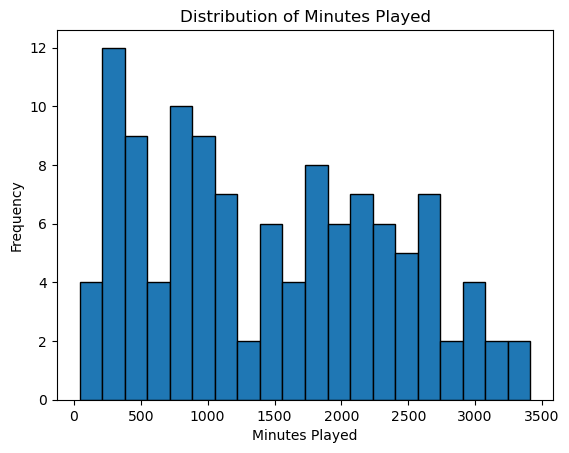

In [166]:
plt.hist(fw_players['Minutes'], bins=20, edgecolor='black')
plt.title('Distribution of Minutes Played')
plt.xlabel('Minutes Played')
plt.ylabel('Frequency')
plt.show()

 Most players cluster around 1000 to 2000 minutes, with a few high-minute outliers. It is definitely still skewed towards the right however.

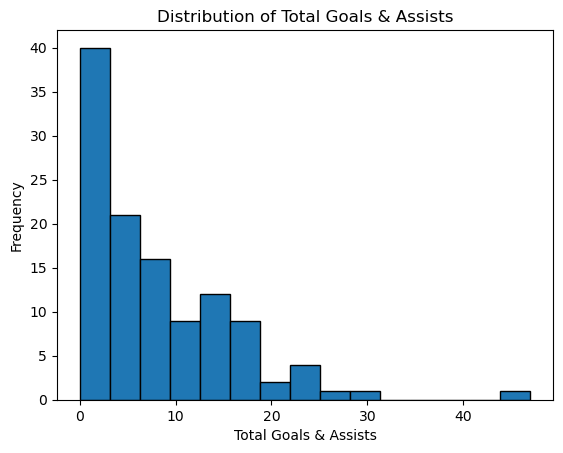

In [168]:
plt.hist(fw_players['Goals & Assists'], bins=15, edgecolor='black')
plt.title('Distribution of Total Goals & Assists')
plt.xlabel('Total Goals & Assists')
plt.ylabel('Frequency')
plt.show()

Goals & Assists is right-skewed, with most forwards having fewer than 10 combined goals and assists, and a few having much higher totals.

#### Scatterplot: Minutes Played vs Goals & Assists

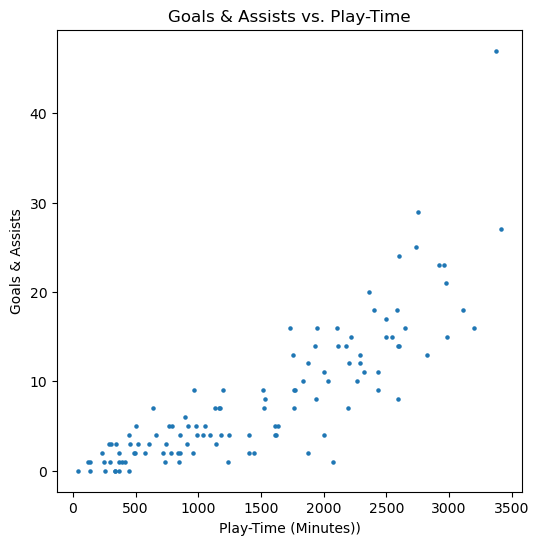

In [171]:
fig = plt.figure(figsize = (6, 6))
plt.scatter(x = fw_players['Minutes'], 
            y = fw_players['Goals & Assists'], 
            s = 5)
plt.xlabel("Play-Time (Minutes))")
plt.ylabel("Goals & Assists")
plt.title("Goals & Assists vs. Play-Time")
plt.show()


The scatterplot shows a clear positive trend: forwards who play more minutes tend to have higher combined goals and assists. While there is some variability, the relationship appears roughly linear, supporting the use of linear regression.

#### Correlation Coefficient

In [174]:
correlation = fw_players['Minutes'].corr(fw_players['Goals & Assists'])
correlation

0.8331409483629341

The correlation coefficient is 0.83, indicating a strong positive relationship between minutes played and total goals + assists. This further supports using linear regression for modeling.

#### Analysis of EDA

Overall, the exploratory data analysis shows that the dataset is clean. While there are some assumptions that still need to be met (such as outliers), the Histograms and summary statistics confirm expected distributions, and the scatterplot along with the correlation coefficient indicate a strong positive relationship between minutes played and goals & assists.

### Regression Model and Assumptions

#### Fitting the Linear Regression

In [180]:
X = sm.add_constant(fw_players['Minutes'])
y = fw_players['Goals & Assists']

mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())

fw_players['residuals'] = res.resid
fw_players['fittedvalues'] = res.fittedvalues

                            OLS Regression Results                            
Dep. Variable:        Goals & Assists   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     258.7
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           4.23e-31
Time:                        20:18:27   Log-Likelihood:                -332.26
No. Observations:                 116   AIC:                             668.5
Df Residuals:                     114   BIC:                             674.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3025      0.761     -3.027      0.0

The regression shows a strong, statistically significant relationship between minutes played and combined goals & assists for forwards. The model explains nearly 70% of the variance, and each additional minute increases expected goals & assists slightly but meaningfully. While residuals are not perfectly normal, the overall linear trend is strong and appropriate for prediction and interpretation.

#### OLS regression line with our scatterplot

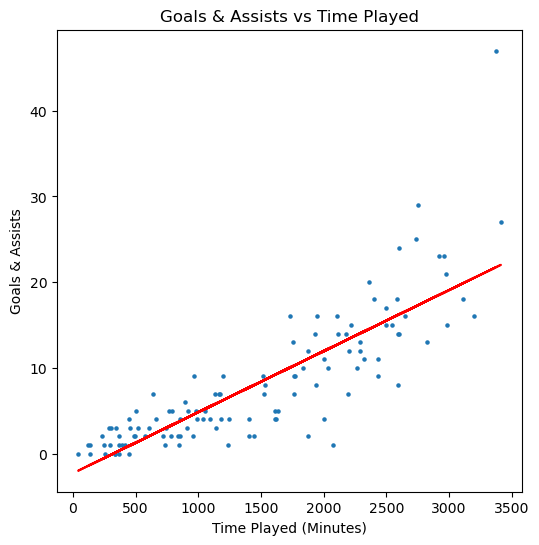

In [183]:
x = fw_players['Minutes']
y = fw_players['Goals & Assists']
fig = plt.figure(figsize=(6,6))
plt.scatter(x, y, s=5)
plt.plot(x, res.params['const'] + res.params['Minutes'] * x, 'r')
plt.xlabel("Time Played (Minutes)")
plt.ylabel("Goals & Assists")
plt.title('Goals & Assists vs Time Played')
plt.show()

#### (L) X vs Y linear (3 diagonostic tools)

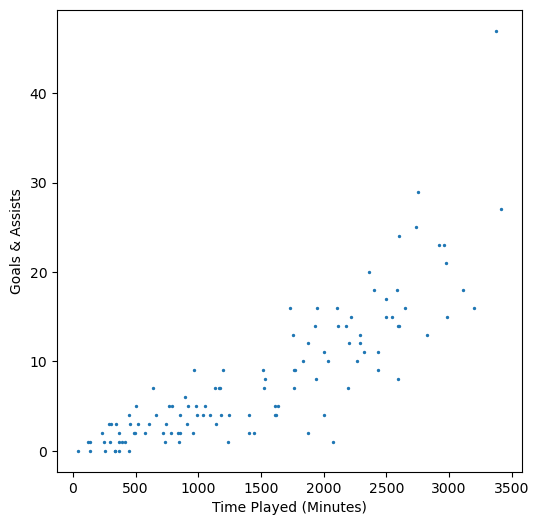

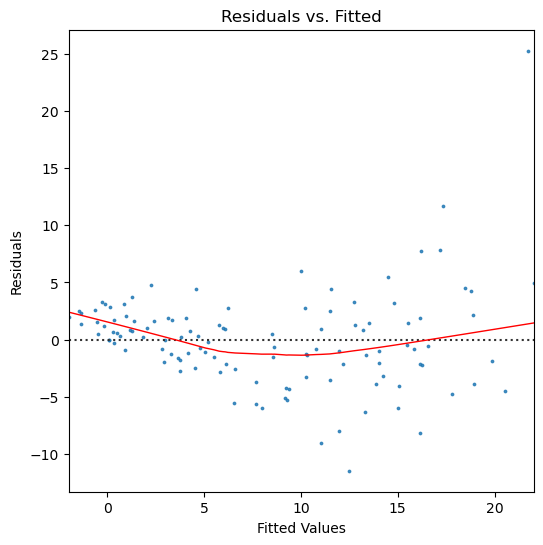

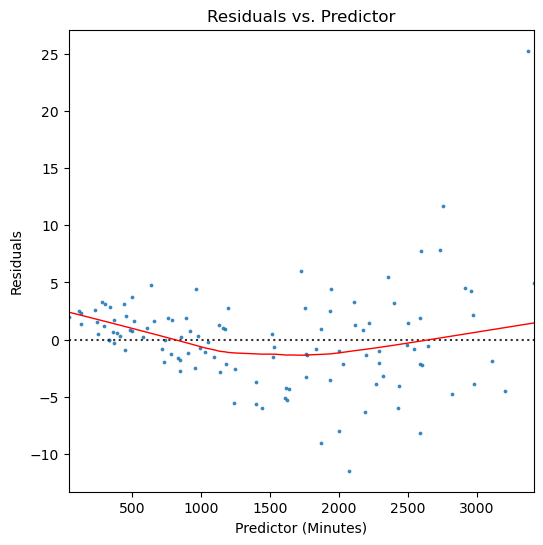

In [185]:
# (L) X vs Y is Linear
fig = plt.figure(figsize = (6, 6))
plt.scatter(x = fw_players['Minutes'], 
            y = fw_players['Goals & Assists'], 
            s = 2)
plt.xlabel("Time Played (Minutes)")
plt.ylabel("Goals & Assists")
plt.show()

# Residuals vs. Fitted Values Plot
fig = plt.figure(figsize = (6, 6))
sns.residplot(x = res.fittedvalues, 
              y = res.resid,
              lowess = True,
              scatter_kws = {'s': 3},
              line_kws = {'color': 'red', 'lw': 1})
plt.title("Residuals vs. Fitted")
plt.ylabel("Residuals")
plt.xlabel("Fitted Values")
plt.show()

# Residuals vs. Predictor Plot
fig = plt.figure(figsize = (6, 6))
sns.residplot(x = fw_players['Minutes'], 
              y = res.resid,
              lowess = True,
              scatter_kws = {'s': 3},
              line_kws = {'color': 'red', 'lw': 1})
plt.title("Residuals vs. Predictor")
plt.xlabel("Predictor (Minutes)")
plt.ylabel("Residuals")
plt.show()

The residual vs. predictor plot shows a shallow U-shaped pattern. This shows that the relationship between minutes and G/A is not perfectly linear. This means that the linearity assumption is violated, because the linear model tends to underestimate G/A  at medium amount of minutes and overestimate it at the extremes. There is a clear pattern.

#### (I) Are the residuals independent?

Most observations are independent because each row represents a single player. However, players on the same team may have residuals that are slightly correlated due to shared team tactics or quality of teammates. For this simple regression, we assume these effects are small and do not substantially affect the independence of residuals.

#### (N) The residuals are normally distributed and centered at zero (all four diagnostic tools)

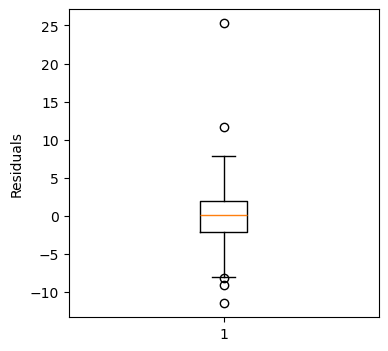

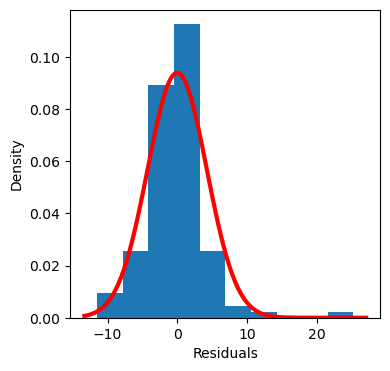

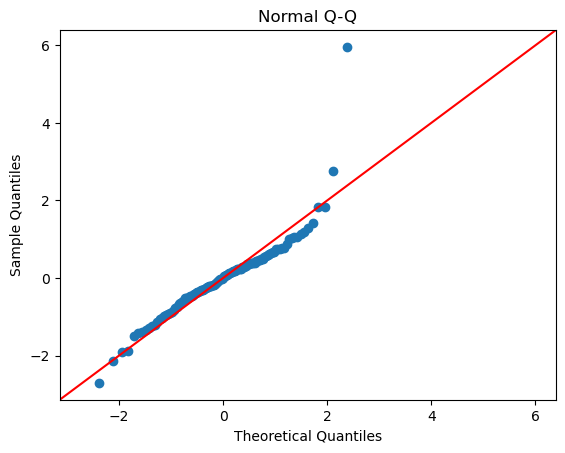

ShapiroResult(statistic=0.8798511289482831, pvalue=3.154093468268737e-08)

In [190]:
# Boxplot
fig = plt.figure(figsize = (4, 4))
plt.boxplot(res.resid)
plt.ylabel("Residuals")
plt.show()

# Histogram
fig = plt.figure(figsize = (4, 4))
plt.hist(res.resid, 
         density = True, 
         bins = 10)
plt.xlabel("Residuals")
plt.ylabel("Density")

# calculate mean and standard deviation
mean = np.mean(res.resid)
sd = np.std(res.resid)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

plt.plot(x,
         stats.norm.pdf(x, mean, sd), 
         color = 'r',
         lw = 3)
plt.show()

# Q-Q Plot (Normal Probability Plot)
sm.qqplot(res.resid, 
          line = '45', 
          fit = True)
plt.title("Normal Q-Q")
plt.show()

# Shapiro-Wilk Test
stats.shapiro(res.resid)

The residuals are not perfectly normally distributed, as indicated by the Shapiro–Wilk test (p ≈ 0). Most residuals cluster near zero, but a few extreme positive values create a long right tail. The histogram shows most residuals near 0, with very low density for the large positive residuals, and the Q-Q plot confirms that these high-end residuals deviate above the reference line. Overall, normality is violated due to these high-end outliers, though the bulk of the residuals behaves reasonably well.

#### (E) The residuals have equal/constant variance across all values of X (one diagnostic tool)

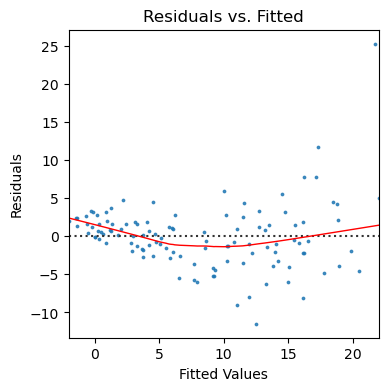

In [193]:
# Residuals vs. Fitted Values Plot
fig = plt.figure(figsize = (4, 4))
sns.residplot(x = res.fittedvalues, 
              y = res.resid,
              lowess = True,
              scatter_kws = {'s': 3},
              line_kws = {'color': 'red', 'lw': 1})
plt.title("Residuals vs. Fitted")
plt.ylabel("Residuals")
plt.xlabel("Fitted Values")
plt.show()


The residuals vs. fitted values plot shows that the spread of residuals is roughly consistent for low to mid fitted values but increases at higher fitted values, indicating some heteroscedasticity. Overall, the constant variance assumption is somewhat violated, and predictions at higher fitted values may be less reliable.

#### 18. (A) The model describes all observations (i.e., there are no influential points)

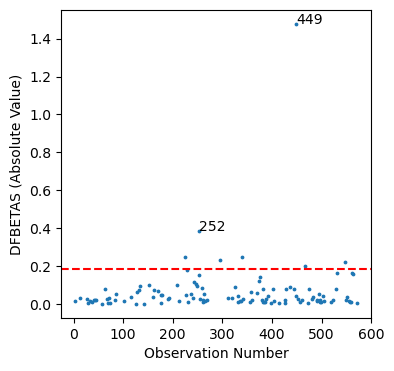

In [196]:
# DFBETAS
fw_players['dfbetas'] = res.get_influence().dfbetas[:, 1]

fig, ax = plt.subplots(figsize = (4, 4))
ax.set_ylabel("DFBETAS (Absolute Value)")
ax.set_xlabel("Observation Number")

ax.scatter(fw_players.index, np.abs(fw_players['dfbetas']), s = 3)
ax.axhline(y = 2 / np.sqrt(len(fw_players)), color = 'r', linestyle = 'dashed')

y_cutoff_dfbetas = 0.25        
outliers_dfbetas = fw_players[np.abs(fw_players['dfbetas']) > y_cutoff_dfbetas]
for i in outliers_dfbetas.index:
    ax.annotate(str(i), (i, np.abs(fw_players['dfbetas'][i])))

plt.show()

In [197]:
df.iloc[449]

Name               Mohamed Salah
Position                      FW
Club                   Liverpool
Age                         32.0
Matches Played                38
Starts                        38
Minutes                     3371
Goals                         29
Assists                       18
Goals & Assists               47
Name: 449, dtype: object

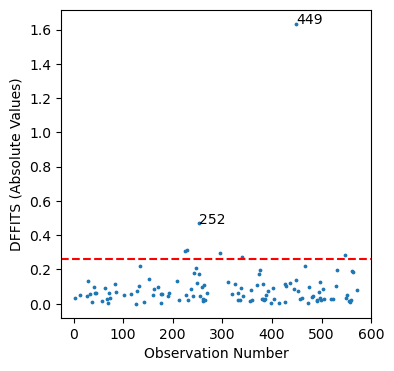

In [198]:
# DFFITS
fw_players['dffits'] = res.get_influence().dffits[0]

fig, ax = plt.subplots(figsize = (4, 4))
ax.set_ylabel("DFFITS (Absolute Values)")
ax.set_xlabel("Observation Number")

ax.scatter(fw_players.index, np.abs(fw_players['dffits']), s = 3)
ax.axhline(y = 2 * np.sqrt(len(res.params) / len(fw_players)), color = 'r', linestyle = 'dashed')

# Label outliers
y_cutoff_dffits = 0.35
outliers_dffits = fw_players[np.abs(fw_players['dffits']) > y_cutoff_dffits]
for i in outliers_dffits.index:
    ax.annotate(str(i), (i, np.abs(fw_players['dffits'][i])))                

plt.show()

Observation 449 (Mohamed Salah) is highly influential, with DFBETAS around 1.45, well above the typical cutoff of 0.2. His minutes and combined goals & assists are extreme compared to the rest of the forwards. While these values are exceptional, they are plausible, as record-breaking players like Salah (and past seasons’ Haaland) can achieve similarly high stats.

I am including this observation for now because it reflects real outcomes, but it does disproportionately affect the regression slope. After applying a transformation to improve model assumptions, I will re-evaluate whether this observation remains influential and, if necessary, consider removing it to see how it changes the regression results.

#### (R) Are Additional predictor variables not needed?

The assumptions are not fully met. While we are using minutes played as the sole predictor for Goals & Assists, other variables could improve the model’s predictive power. For example, the player’s age, position nuances (FW vs. FW,MF), team strength, or expected goals (xG) might help explain the variation in Goals & Assists more accurately.

### Transformation and its Regression Assumptions

#### Model Square Root Transformation

The residuals from the original model show a shallow U-shaped pattern, some right skew, and increasing spread at higher fitted values, indicating minor violations of linearity, normality, and constant variance. Observation 449 (Mohamed Salah) is highly influential. So I do want to address these issues, to help me find which type of transfomration I want to use for normality  I decided to plot the sqrt transformation, log transformation and our original histogram for Goals & Assists.

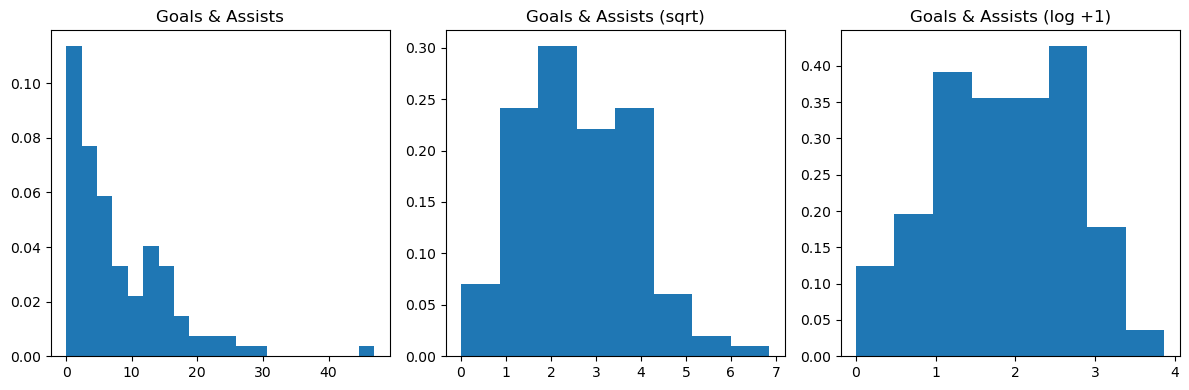

In [204]:
# Square root and log transformations
G_A_sqrt_trans = np.sqrt(fw_players['Goals & Assists'])
G_A_log_trans = np.log(fw_players['Goals & Assists'] + 1)  # add 1 to avoid log(0)

# Function to plot histograms
def hist_Y(variable, bin_size, ax, title):
    ax.hist(variable, density=True, bins=bin_size)
    ax.set_title(title)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
hist_Y(fw_players['Goals & Assists'], 20, axes[0], 'Goals & Assists')  # original
hist_Y(G_A_sqrt_trans, 8, axes[1], 'Goals & Assists (sqrt)')  # sqrt
hist_Y(G_A_log_trans, 8, axes[2], 'Goals & Assists (log +1)')  # log +1
fig.tight_layout()
plt.show()

Both the log (+1) and square root transformations help with skew and make the residuals more normal. The log looks a bit more symmetric, but we had to add 1 because some players had zero goals and assists. Those zeros actually matter, they show which players didn’t score or assist at all, so ignoring them would bias the model. The square root transformation also reduces skew and stabilizes variance, while keeping the differences between low, medium, and high values clear. Because of that, I went with the square root, it improves normality but still makes sense with the data and keeps the zeros meaningful.

In [206]:
fw_players['Goals & Assists_trans'] = np.sqrt(fw_players['Goals & Assists'])
X = sm.add_constant(fw_players['Minutes'])
y = fw_players['Goals & Assists_trans']
mod = sm.OLS(y, X)
res_trans = mod.fit()
print(res_trans.summary())
fw_players['residuals_trans'] = res_trans.resid
fw_players['fittedvalues_trans'] = res_trans.fittedvalues

                              OLS Regression Results                             
Dep. Variable:     Goals & Assists_trans   R-squared:                       0.757
Model:                               OLS   Adj. R-squared:                  0.755
Method:                    Least Squares   F-statistic:                     355.4
Date:                   Wed, 24 Sep 2025   Prob (F-statistic):           7.85e-37
Time:                           20:18:29   Log-Likelihood:                -116.37
No. Observations:                    116   AIC:                             236.7
Df Residuals:                        114   BIC:                             242.2
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6158 

#### (L) X vs Y linear (3 diagonostic tools) Transformed Model

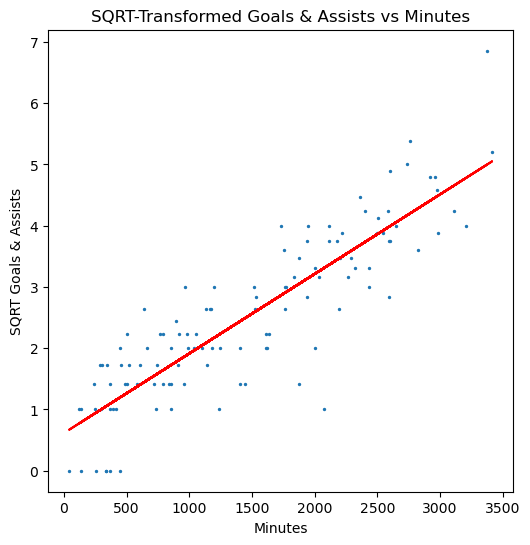

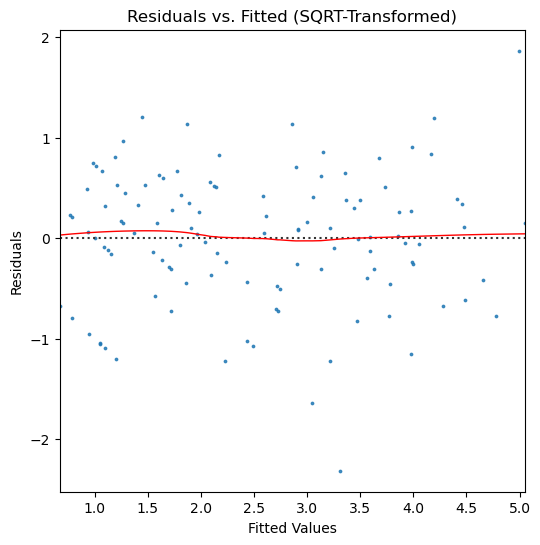

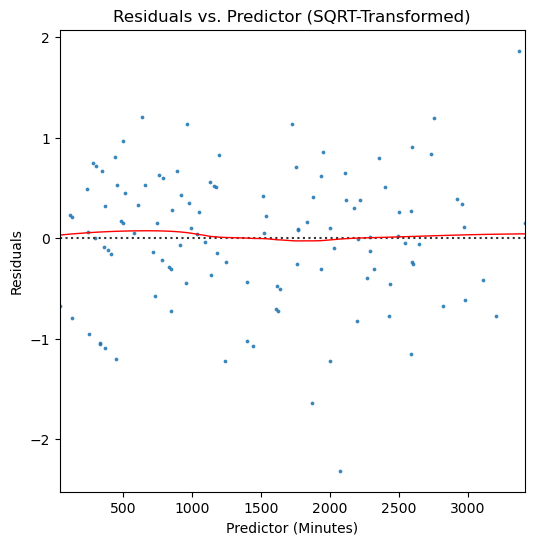

In [208]:
fig = plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(fw_players['Minutes'], 
            fw_players['Goals & Assists_trans'], 
            s=2, 
            label='Data')

# Add OLS regression line from sqrt-transformed model
plt.plot(fw_players['Minutes'], fw_players['fittedvalues_trans'], color='red')
plt.xlabel("Minutes")
plt.ylabel("SQRT Goals & Assists")
plt.title("SQRT-Transformed Goals & Assists vs Minutes")
plt.show()

# --- Residuals vs. Fitted Values Plot ---
fig = plt.figure(figsize=(6, 6))
sns.residplot(x=fw_players['fittedvalues_trans'], 
              y=fw_players['residuals_trans'],
              lowess=True,
              scatter_kws={'s': 3},
              line_kws={'color': 'red', 'lw': 1})
plt.title("Residuals vs. Fitted (SQRT-Transformed)")
plt.ylabel("Residuals")
plt.xlabel("Fitted Values")
plt.show()

# --- Residuals vs. Predictor Plot ---
fig = plt.figure(figsize=(6, 6))
sns.residplot(x=fw_players['Minutes'], 
              y=fw_players['residuals_trans'],
              lowess=True,
              scatter_kws={'s': 3},
              line_kws={'color': 'red', 'lw': 1})
plt.title("Residuals vs. Predictor (SQRT-Transformed)")
plt.xlabel("Predictor (Minutes)")
plt.ylabel("Residuals")
plt.show()

The scatter plot with the OLS line shows a clear positive relationship between Minutes and sqrt(Goals & Assists), with most points hugging the regression line. The residuals vs. fitted values plot looks pretty random around zero, which means the linearity assumption is holding up after the sqrt transformation. The residuals vs. predictor plot also doesn’t show any obvious curves, so the shallow U-shape we saw in the original data is mostly gone. Overall, the relationship between Minutes and sqrt(Goals & Assists) is now roughly linear.

#### (N) The residuals are normally distributed and centered at zero (used all four diagnostic tools) Transformed Model

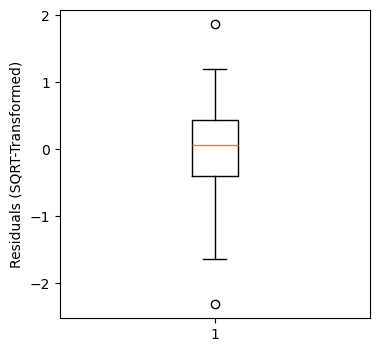

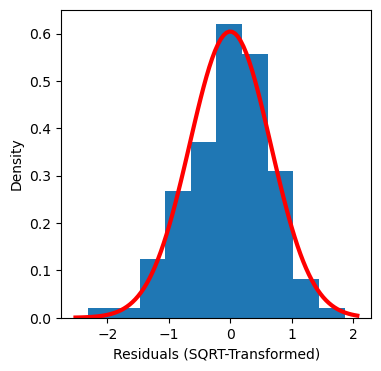

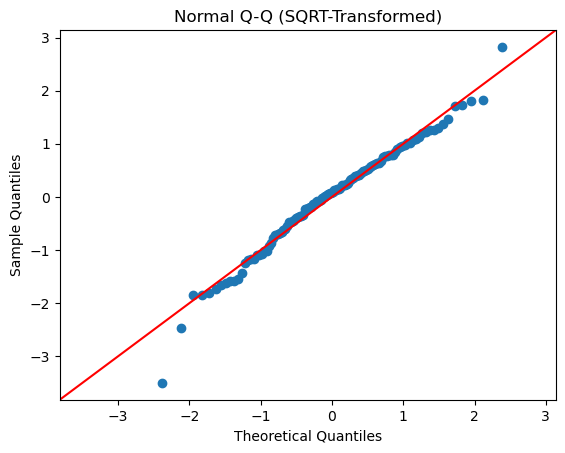

ShapiroResult(statistic=0.9849694949254022, pvalue=0.22324084220579604)

In [231]:
# --- Residuals Normality Checks ---
# Boxplot
fig = plt.figure(figsize=(4, 4))
plt.boxplot(fw_players['residuals_trans'])
plt.ylabel("Residuals (SQRT-Transformed)")
plt.show()

# Histogram with normal curve
fig = plt.figure(figsize=(4, 4))
plt.hist(fw_players['residuals_trans'], 
         density=True, 
         bins=10)
plt.xlabel("Residuals (SQRT-Transformed)")
plt.ylabel("Density")
mean = np.mean(fw_players['residuals_trans'])
sd = np.std(fw_players['residuals_trans'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, stats.norm.pdf(x, mean, sd), color='r', lw=3)
plt.show()

# Q-Q Plot
sm.qqplot(fw_players['residuals_trans'], line='45', fit=True)
plt.title("Normal Q-Q (SQRT-Transformed)")
plt.show()

# Shapiro-Wilk Test
stats.shapiro(fw_players['residuals_trans'])

The residuals for the sqrt-transformed model look more symmetric than in the original model. The boxplot and histogram show most residuals are close to zero, with fewer extreme values and less right skew. The Q-Q plot also has most points hugging the reference line, which suggests the residuals are roughly normal. The Shapiro-Wilk test agrees, with a p-value of 0.223, so we can’t reject normality. Overall, the sqrt transformation did a good job of improving the residuals’ distribution.

#### (E) The residuals have equal/constant variance across all values of X New Model

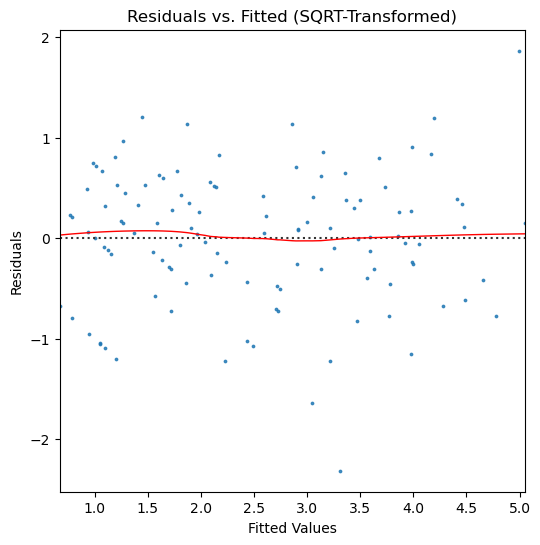

In [235]:
# --- Residuals vs. Fitted Values Plot ---
fig = plt.figure(figsize=(6, 6))
sns.residplot(x=fw_players['fittedvalues_trans'], 
              y=fw_players['residuals_trans'],
              lowess=True,
              scatter_kws={'s': 3},
              line_kws={'color': 'red', 'lw': 1})
plt.title("Residuals vs. Fitted (SQRT-Transformed)")
plt.ylabel("Residuals")
plt.xlabel("Fitted Values")
plt.show()

The residuals vs. fitted values plot for the sqrt-transformed model shows that the residuals are pretty evenly spread across all fitted values. There’s no obvious funnel shape or trend up or down, which means the equal variance assumption (homoscedasticity) looks good after the transformation.

#### (A) The model describes all observations (i.e., there are no influential points) Transformed Model

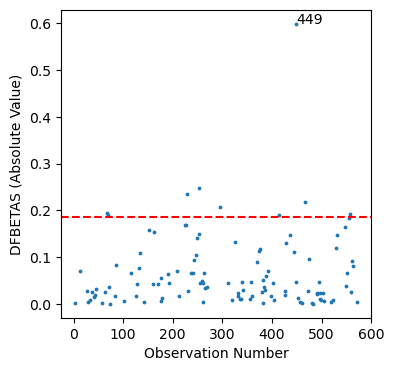

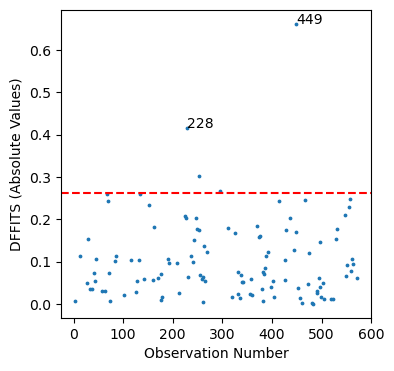

In [239]:
#DFBETAS
fw_players['dfbetas_trans'] = res_trans.get_influence().dfbetas[:, 1]

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel("DFBETAS (Absolute Value)")
ax.set_xlabel("Observation Number")

ax.scatter(fw_players.index, np.abs(fw_players['dfbetas_trans']), s=3)
ax.axhline(y=2 / np.sqrt(len(fw_players)), color='r', linestyle='dashed')

y_cutoff_dfbetas = 0.25
outliers_dfbetas = fw_players[np.abs(fw_players['dfbetas_trans']) > y_cutoff_dfbetas]
for i in outliers_dfbetas.index:
    ax.annotate(str(i), (i, np.abs(fw_players['dfbetas_trans'][i])))
plt.show()

# DFFITS
fw_players['dffits_trans'] = res_trans.get_influence().dffits[0]

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel("DFFITS (Absolute Values)")
ax.set_xlabel("Observation Number")

ax.scatter(fw_players.index, np.abs(fw_players['dffits_trans']), s=3)
ax.axhline(y=2 * np.sqrt(len(res_trans.params) / len(fw_players)), color='r', linestyle='dashed')

y_cutoff_dffits = 0.35
outliers_dffits = fw_players[np.abs(fw_players['dffits_trans']) > y_cutoff_dffits]
for i in outliers_dffits.index:
    ax.annotate(str(i), (i, np.abs(fw_players['dffits_trans'][i])))                
plt.show()

The DFBETAS and DFFITS plots for the sqrt-transformed model show that most points are below the influence cutoffs, so they’re not having a big effect on the regression. Observation 449 is still a clear outlier, with influence measures way above the thresholds. Its values are extreme but plausible, so I’ve decided to remove it for now to keep it from skewing the regression slope and to help the model better meet the assumptions.

In [242]:
fw_players = fw_players.drop(index=449)

### Model Assessment and Statistical Inference

#### Fitted Curve on Original Data

In this section, I assess the performance of the final regression model and use it to make statistical inferences about the relationship between Minutes Played and Goals & Assists.

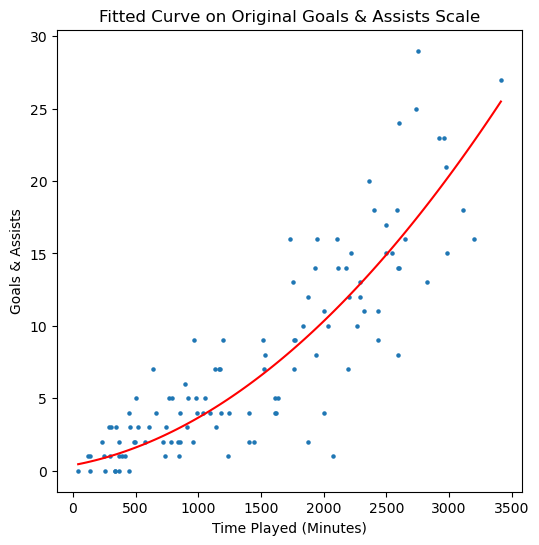

In [247]:
# Create a sequence of Minutes values for prediction
minutes_values = np.linspace(fw_players['Minutes'].min(), fw_players['Minutes'].max(), num=100)

# Predict sqrt(Goals & Assists) using the sqrt-transformed model
X = sm.add_constant(pd.DataFrame({'Minutes': minutes_values}))
ga_preds_sqrt = res_trans.predict(X)

# Back-transform to original Goals & Assists scale
ga_preds = ga_preds_sqrt ** 2

# Store results in a DataFrame for plotting
preds = pd.DataFrame({"Minutes_values": minutes_values, "GA_preds": ga_preds})

# Plot the predictions on the original scale
def plot_minutes_vs_ga(x, y):
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=5)
    plt.plot(preds['Minutes_values'], preds['GA_preds'], color='r')
    plt.xlabel("Time Played (Minutes)")
    plt.ylabel("Goals & Assists")
    plt.title("Fitted Curve on Original Goals & Assists Scale")

plot_minutes_vs_ga(fw_players['Minutes'], fw_players['Goals & Assists'])
plt.show()

#### Confidence Interval for Slope

In [250]:
fw_players['residuals_trans'] = res_trans.resid
fw_players['fittedvalues_trans'] = res_trans.fittedvalues
fw_players['fittedvalues_orig_scale'] = res_trans.fittedvalues ** 2
fw_players.head()

,Name,Position,Club,Age,Matches Played,Starts,Minutes,Goals,Assists,Goals & Assists,residuals,fittedvalues,dfbetas,dffits,Goals & Assists_trans,residuals_trans,fittedvalues_trans,dfbetas_trans,dffits_trans,fittedvalues_orig_scale
4,Simon Adingra,"FW,MF",Brighton,22.0,29,12,1097,2,2,4,-1.512721,5.512721,0.013515,-0.035677,2.000000,-0.040285,2.040285,0.002313,-0.006107,4.162763
13,Carlos Alcaraz,"FW,MF",Everton,21.0,15,7,764,2,3,5,1.859620,3.140380,-0.031809,0.051701,2.236068,0.628186,1.607882,-0.069320,0.112670,2.585283
27,Michail Antonio,FW,West Ham,34.0,14,11,836,1,1,2,-1.653319,3.653319,0.025342,-0.044182,1.414214,-0.287161,1.701374,0.028311,-0.049359,2.894674
30,Cameron Archer,FW,Southampton,23.0,35,13,1441,2,0,2,-5.963428,7.963428,0.003400,-0.131076,1.414214,-1.072759,2.486972,0.003945,-0.152088,6.185031
33,Adam Armstrong,"FW,MF",Southampton,27.0,20,15,1248,2,2,4,-2.588468,6.588468,0.013620,-0.058123,2.000000,-0.236360,2.236360,0.007990,-0.034095,5.001306


In [252]:
res_trans.conf_int().loc['Minutes']

0    0.001162
1    0.001435
Name: Minutes, dtype: float64

We are 95% confident that each additional minute played is associated with an increase of approximately 0.0012 to 0.0014 in the square root of expected Goals & Assists. Over a full 90-minute match, this corresponds to an increase of roughly 0.11 to 0.13 in the square root of Goals & Assists. 

#### Hypothesis Test of Slope

In [256]:
print("The test statistic for Minutes is ", 
      round(res_trans.tvalues['Minutes'], 2), 
      " and the corresponding p-value is ",
      res_trans.pvalues['Minutes'])

The test statistic for Minutes is  18.85  and the corresponding p-value is  7.847628491547053e-37


Since the p-value is far below the standard level of 0.05, we reject the null hypothesis. This indicates very strong evidence that playing more minutes is associated with a statistically significant increase in combined goals and assists.

#### CI mean of Y and Confidence Band

In [260]:
pred = res_trans.get_prediction([1, 1710])
# Grab just the confidence interval for the mean
ci_sqrt = pred.summary_frame(alpha=0.05).loc[:, ['mean_ci_lower', 'mean_ci_upper']]
ci_original = ci_sqrt ** 2
ci_original


,mean_ci_lower,mean_ci_upper
0,7.340509,8.780584


We are 95% confident that players who play approximately half the season (1,710 minutes) will average between 7.34 and 8.78 total Goals & Assists during that time.

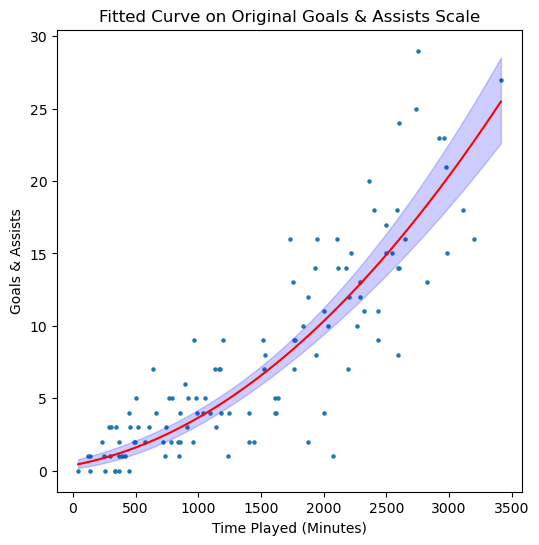

In [263]:
# Define Speed values to predict
x = np.linspace(fw_players['Minutes'].min(),
                fw_players['Minutes'].max(),
                num=200)
X = np.vstack((np.ones(200), x)).T

# Predict and store results with confidence intervals
pred_trans = res_trans.get_prediction(X).summary_frame(alpha=0.05)

# Plot the predictions
plot_minutes_vs_ga(fw_players['Minutes'], fw_players['Goals & Assists'])
plt.fill_between(x,
                 pred_trans['mean_ci_lower']**2,
                 pred_trans['mean_ci_upper']**2,
                 color='blue',
                 alpha=0.2)
plt.show()

#### Prediciton interval for Y and Prediction Band

In [313]:
pred = res_trans.get_prediction([1, 1710])
pred_interval_sqrt = pred.summary_frame(alpha=0.05).loc[:, ['obs_ci_lower', 'obs_ci_upper']]
pred_interval = pred_interval_sqrt ** 2
pred_interval

,obs_ci_lower,obs_ci_upper
0,2.284938,17.31343


We are 95% confident that a new player who plays approximately half the season (1,710 minutes) would have total Goals + Assists between about 2.28 and 17.31. 

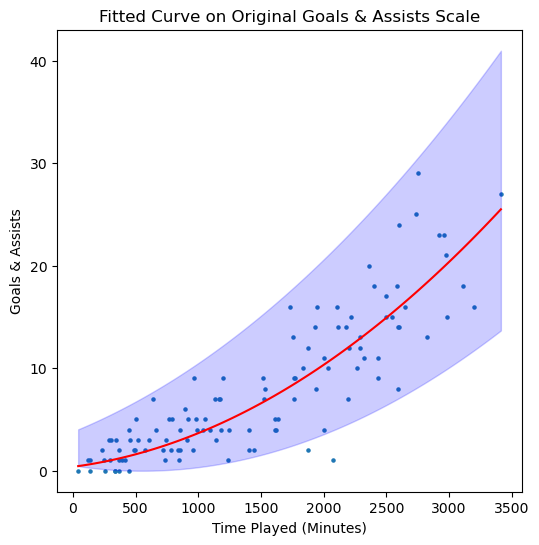

In [269]:
plot_minutes_vs_ga(fw_players['Minutes'], fw_players['Goals & Assists'])

# Fill prediction band (back-transform with square)
plt.fill_between(x,
                 pred_trans['obs_ci_lower']**2,
                 pred_trans['obs_ci_upper']**2,
                 color='blue',
                 alpha=0.2)
plt.show()

#### MSE

In [279]:
mse = np.sum((fw_players['Goals & Assists'] - fw_players['fittedvalues_orig_scale']) ** 2) / (len(fw_players) - 2)
mse

11.227048360365215

#### RSME

In [282]:
rmse = (((fw_players['Goals & Assists'] - fw_players['fittedvalues_orig_scale']) ** 2).sum() / (len(fw_players) - 2) ) ** 0.5
rmse

3.3506787909862705

The RMSE for our sqrt-transformed model, when back-transformed to the original scale of Goals & Assists, is approximately 3.35. This indicates that, on average, the model’s predictions are off by about 3.35 Goals & Assists per player. Considering that forwards in our dataset typically have Goals & Assists ranging from 0 up to around 30, this level of error is moderate. While Minutes played provides some predictive power, there is substantial variation that the model does not capture, suggesting that additional predictors could improve accuracy.

#### MAE

In [286]:
mae = np.sum(np.abs(fw_players['Goals & Assists'] - fw_players['fittedvalues_orig_scale'])) / (len(fw_players) - 2)
mae

2.458523051346813

The MAE is about 2.46, which tells us that, on average, our model’s predictions for combined Goals & Assists are off by around 2.46 goals or assists per player. Unlike RMSE, it doesn’t square the differences, so it’s less affected by extreme mistakes and gives a more straightforward idea of how far off our predictions usually are.

#### R Squared

In [293]:
round(res_trans.rsquared, 4)

0.7572

The R squared for our model is 0.7572, which means that about 76% of the variation in combined Goals & Assists can be explained by minutes played. The remaining 24% of the variation is due to other factors not included in the model or random differences between players. Overall, the model does a fairly good job capturing the relationship.

In [298]:
round(res_trans.rsquared_adj, 4)

0.755

The adjusted R² is 0.755, which is very close to the regular R². This means that about 76% of the variation in combined goals + assists can be explained by minutes played, even after accounting for the number of predictors in the model. So, the model is still at a good state.

#### F statistic and p-value

In [303]:
print("The test statistic for the F-test is ",
      round(res_trans.fvalue, 2), 
      " and the corresponding p-value is ", 
      res_trans.f_pvalue)

The test statistic for the F-test is  355.45  and the corresponding p-value is  7.84762849154698e-37


The F-test statistic is 355.45 and the p-value is basically 0. This basically checks if our model actually does something useful — in this case, whether minutes played helps explain combined goals + assists. Since the p-value is super small, we can say the model is significant, so minutes do help predict goals + assists.

### Conclusion

In this analysis, I looked at how minutes played predicts combined Goals & Assists for forwards. My initial regression model showed some issues with nonlinearity, heteroscedasticity, and influential outliers. Applying a square root transformation to Goals & Assists helped fix those problems, making the model more reliable.

The results show that minutes played is a significant predictor of goals and assists. The RMSE and MAE tell me that the model’s predictions are reasonably close to the actual values, and the R² indicates that about 75% of the variation in combined goals and assists can be explained by playing time. Confidence intervals for the slope and predicted values give me an idea of how much Goals & Assists increase with more minutes played, and prediction intervals show the range of likely outcomes for players at different amounts of playing time.

Overall, minutes played clearly matters for predicting a forward’s performance, though I know other factors-like team quality, position details, or expected goals could improve the model even more.